# Predictive Analytics Using Historical Sales Data

## Project Overview

This project uses historical sales data to forecast future revenue using machine learning.

## Objectives

- Clean and preprocess historical sales data
- Analyze monthly revenue trends
- Build a Linear Regression prediction model
- Evaluate model performance
- Forecast future revenue
- Generate business insights

## Technologies Used

Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Jupyter Notebook

## Machine Learning Model

Linear Regression

## Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

## Output

The project produces:
- Historical revenue visualization
- Actual vs predicted revenue visualization
- Future revenue forecast
- Business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("data/sales_data.xlsx")

df.head()

,Date,Region,Category,Product,Salesperson,Quantity,Unit Price,Revenue
0,2026-01-05,North,Electronics,Laptop,Alice,2,750,1500
1,2026-01-08,South,Furniture,Office Chair,Bob,5,120,600
2,2026-01-12,East,Electronics,Headphones,Carol,10,45,450
3,2026-01-18,West,Office Supplies,Notebook,David,25,8,200
4,2026-02-03,North,Electronics,Monitor,Alice,4,220,880


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Rows: 24
Columns: 8

Column names:
['Date', 'Region', 'Category', 'Product', 'Salesperson', 'Quantity', 'Unit Price', 'Revenue']

Missing values:
Date           0
Region         0
Category       0
Product        0
Salesperson    0
Quantity       0
Unit Price     0
Revenue        0
dtype: int64


In [4]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Calculate monthly revenue
monthly_data = (
    df.groupby(df["Date"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

# Convert period to datetime
monthly_data["Date"] = monthly_data["Date"].dt.to_timestamp()

monthly_data

,Date,Revenue
0,2026-01-01,2750
1,2026-02-01,2440
2,2026-03-01,4205
3,2026-04-01,3810
4,2026-05-01,5500
5,2026-06-01,4530


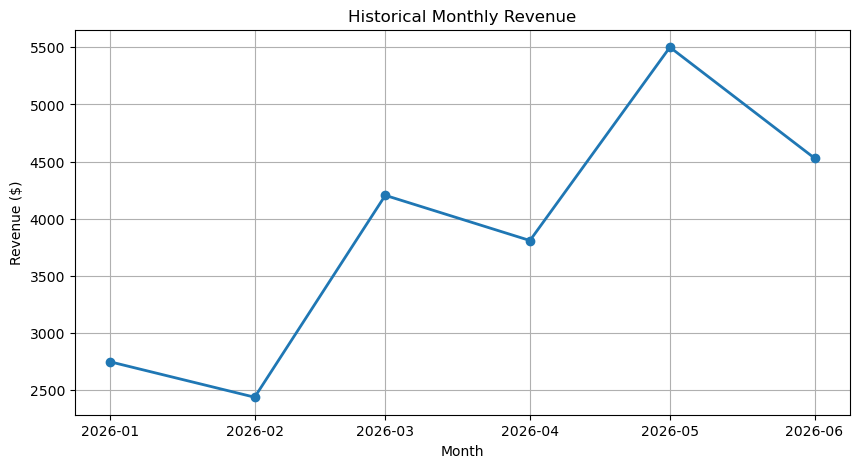

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_data["Date"],
    monthly_data["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Historical Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(True)

plt.show()

In [6]:
# Create a numerical time index
monthly_data["Time"] = np.arange(len(monthly_data))

X = monthly_data[["Time"]]
y = monthly_data["Revenue"]

monthly_data

,Date,Revenue,Time
0,2026-01-01,2750,0
1,2026-02-01,2440,1
2,2026-03-01,4205,2
3,2026-04-01,3810,3
4,2026-05-01,5500,4
5,2026-06-01,4530,5


In [7]:
# Chronological train-test split
train = monthly_data.iloc[:-2]
test = monthly_data.iloc[-2:]

X_train = train[["Time"]]
y_train = train["Revenue"]

X_test = test[["Time"]]
y_test = test["Revenue"]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 4
Testing observations: 2


In [8]:
# Train Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Model trained successfully!
Slope: 494.5
Intercept: 2559.5


In [9]:
# Predict revenue for the test period
test["PredictedRevenue"] = model.predict(X_test)

test

C:\Users\kusuma\AppData\Local\Temp\ipykernel_15628\1474501392.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["PredictedRevenue"] = model.predict(X_test)


,Date,Revenue,Time,PredictedRevenue
4,2026-05-01,5500,4,4537.5
5,2026-06-01,4530,5,5032.0


In [10]:
# Model evaluation

mae = mean_absolute_error(y_test, test["PredictedRevenue"])
mse = mean_squared_error(y_test, test["PredictedRevenue"])
rmse = np.sqrt(mse)
r2 = r2_score(y_test, test["PredictedRevenue"])

print("===== MODEL PERFORMANCE =====")
print(f"MAE  : ${mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.2f}")

===== MODEL PERFORMANCE =====
MAE  : $732.25
MSE  : 589,205.12
RMSE : $767.60
R²   : -1.50


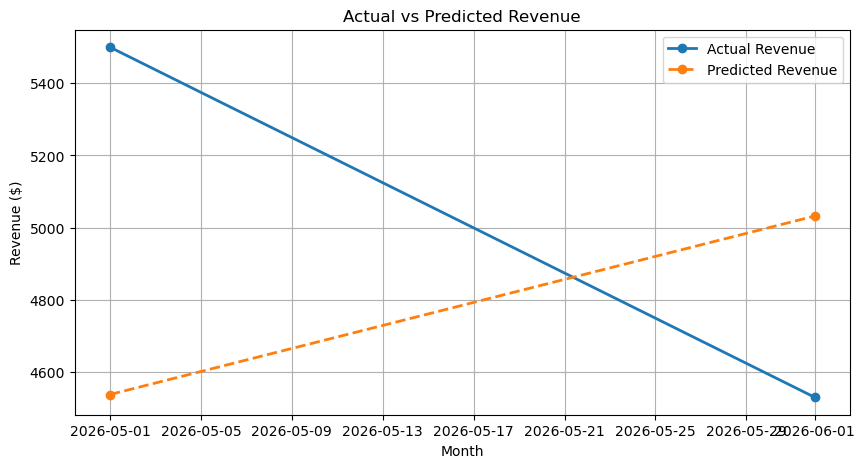

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    test["Date"],
    y_test,
    marker="o",
    linewidth=2,
    label="Actual Revenue"
)

plt.plot(
    test["Date"],
    test["PredictedRevenue"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
# Forecast the next 3 months

last_time = monthly_data["Time"].max()

future = pd.DataFrame({
    "Time": [last_time + 1, last_time + 2, last_time + 3]
})

future["PredictedRevenue"] = model.predict(future)

future_dates = pd.date_range(
    start=monthly_data["Date"].max() + pd.DateOffset(months=1),
    periods=3,
    freq="MS"
)

future["Date"] = future_dates

future = future[["Date", "Time", "PredictedRevenue"]]

future

,Date,Time,PredictedRevenue
0,2026-07-01,6,5526.5
1,2026-08-01,7,6021.0
2,2026-09-01,8,6515.5


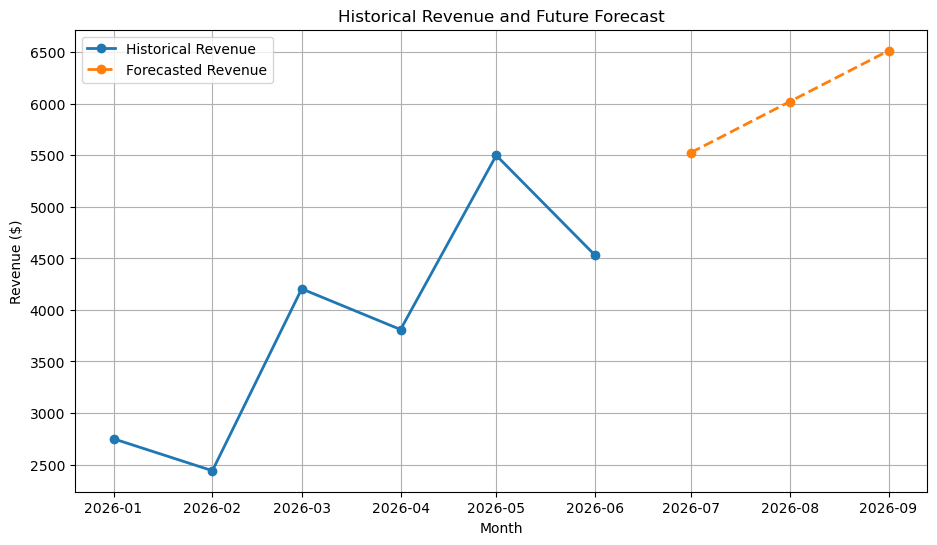

In [13]:
plt.figure(figsize=(11, 6))

# Historical revenue
plt.plot(
    monthly_data["Date"],
    monthly_data["Revenue"],
    marker="o",
    linewidth=2,
    label="Historical Revenue"
)

# Future predictions
plt.plot(
    future["Date"],
    future["PredictedRevenue"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Forecasted Revenue"
)

plt.title("Historical Revenue and Future Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(True)

plt.show()

# Business Insights & Recommendations

## Predictive Analytics Insights

### 1. Historical Revenue Trend
The historical monthly revenue data was analyzed to identify changes and trends over time.

### 2. Prediction Performance
A Linear Regression model was trained on historical revenue data and evaluated using MAE, MSE, RMSE, and R².

### 3. Future Revenue Forecast
The trained model was used to forecast revenue for the next three months.

### 4. Business Recommendations
- Use revenue forecasts for sales and inventory planning.
- Monitor months where predicted revenue shows a decline.
- Prepare marketing campaigns during periods of expected lower sales.
- Use historical trends to support budgeting and resource allocation.
- Retrain the model regularly when new sales data becomes available.

## Conclusion

This project demonstrates how historical sales data can be cleaned, analyzed, visualized, and used to build a predictive model for future revenue forecasting.

In [14]:
# Save forecast results

future.to_csv(
    "data/future_revenue_forecast.csv",
    index=False
)

test.to_csv(
    "data/test_predictions.csv",
    index=False
)

print("Forecast results saved successfully!")

Forecast results saved successfully!
